In [29]:
 # Proyek analisis penjualan coklat
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
#siapkan data
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/Proyek Coding/Chocolate Sales (2).csv')
df

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,"$5,303.58",354
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,"$7,339.32",121
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,$616.09,238
3280,Dotty Strutley,India,Eclairs,28/07/2024,"$2,504.62",397


In [31]:
#Cek dan bersihkan
print(df.info())
display(df.describe())
df.isnull()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB
None


,Boxes Shipped
count,3282.000000
mean,164.666971
std,124.024736
min,1.000000
25%,71.000000
50%,137.000000
75%,232.000000
max,778.000000


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
3277,False,False,False,False,False,False
3278,False,False,False,False,False,False
3279,False,False,False,False,False,False
3280,False,False,False,False,False,False


In [32]:
import numpy as np
#cek data null
df.isnull().sum()

,0
Sales Person,0
Country,0
Product,0
Date,0
Amount,0
Boxes Shipped,0


In [33]:
#cek data duplikat
df.duplicated().sum()
#Hapus dengan df.drop_duplicates()

np.int64(0)

In [34]:
#preposessing
data_ok=df[['Amount','Boxes Shipped']]
data_ok

,Amount,Boxes Shipped
0,"$5,320.00",180
1,"$7,896.00",94
2,"$4,501.00",91
3,"$12,726.00",342
4,"$13,685.00",184
...,...,...
3277,"$5,303.58",354
3278,"$7,339.32",121
3279,$616.09,238
3280,"$2,504.62",397


In [35]:
#hilangkan simbol $ dan ,
# 1. Hapus tanda '$' dan ',' lalu ubah ke float
data_ok['Amount'] = data_ok['Amount'].replace('[\$,]', '', regex=True).astype(float)
data_ok

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_1951/2900059858.py:3: SyntaxWarning: invalid escape sequence '\$'
  data_ok['Amount'] = data_ok['Amount'].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipykernel_1951/2900059858.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_ok['Amount'] = data_ok['Amount'].replace('[\$,]', '', regex=True).astype(float)


,Amount,Boxes Shipped
0,5320.00,180
1,7896.00,94
2,4501.00,91
3,12726.00,342
4,13685.00,184
...,...,...
3277,5303.58,354
3278,7339.32,121
3279,616.09,238
3280,2504.62,397


In [36]:
#scalling biar imbang
from sklearn.preprocessing import StandardScaler
alat_scalling = StandardScaler()
data_scalled = alat_scalling.fit_transform(data_ok[['Boxes Shipped', 'Amount']])
data_scalled

array([[ 0.12364763, -0.16168644],
       [-0.56986809,  0.42465952],
       [-0.5940605 , -0.34810622],
       ...,
       [ 0.59136754, -1.23238466],
       [ 1.87356523, -0.80251978],
       [ 1.5348715 , -0.02605524]])

In [37]:
# Mulai buat model dengan 3 cluster
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)


In [38]:
# Langsung fit tdk perlu split
clusters = kmeans.fit_predict(data_scalled)

# Masukkan hasilnya kembali ke table asli supaya mudah dibaca
df['Cluster_Label'] = clusters
df


,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Cluster_Label
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180,0
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94,2
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91,0
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342,1
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184,2
...,...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,"$5,303.58",354,1
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,"$7,339.32",121,0
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,$616.09,238,0
3280,Dotty Strutley,India,Eclairs,28/07/2024,"$2,504.62",397,1


In [39]:
df['Amount'] = df['Amount'].replace('[$,]', '', regex=True).astype(float)# untukhilangakn simbol $,
print(df.groupby('Cluster_Label')[['Boxes Shipped', 'Amount']].mean())

               Boxes Shipped        Amount
Cluster_Label                             
0                 104.873633   3450.503663
1                 345.886179   5109.170420
2                 125.335189  11516.119220


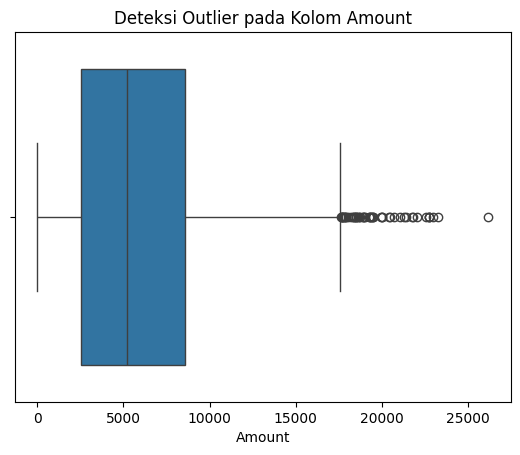

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat Box Plot untuk satu kolom (Amount)
sns.boxplot(x=df['Amount'])
plt.title('Deteksi Outlier pada Kolom Amount')
plt.show()


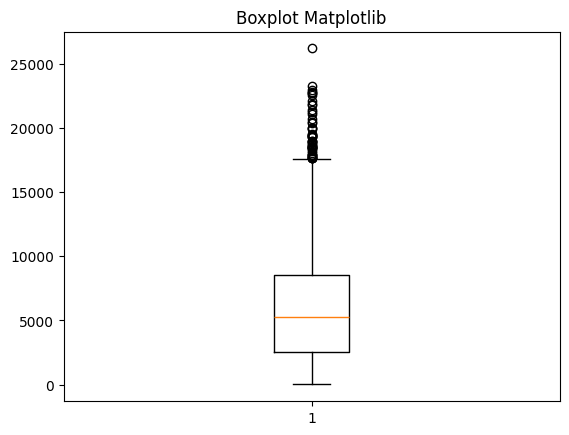

In [41]:
import matplotlib.pyplot as plt
plt.boxplot(df['Amount'])
plt.title("Boxplot Matplotlib")
plt.show()


In [42]:
df

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Cluster_Label
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,5320.00,180,0
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,7896.00,94,2
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,4501.00,91,0
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,12726.00,342,1
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,13685.00,184,2
...,...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,5303.58,354,1
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,7339.32,121,0
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,616.09,238,0
3280,Dotty Strutley,India,Eclairs,28/07/2024,2504.62,397,1


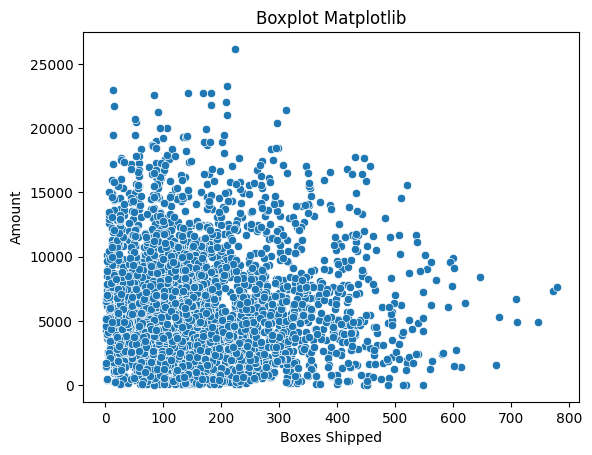

In [43]:
sns.scatterplot(data=df, x='Boxes Shipped', y= 'Amount')
plt.title("Boxplot Matplotlib")
plt.show()

In [44]:
#hilangakan pencilan data
Q1= df['Amount'].quantile(0.25)
Q3= df['Amount'].quantile(0.75)
IQR= Q3-Q1
#tentukan batas pagar
IQR_Lower= Q1-1.5*IQR
IQR_Upper= Q3+1.5*IQR
# Filter data: hanya ambil yang di dalam pagar
df_filtered= df[(df['Amount']>= IQR_Lower)&(df['Amount']<=IQR_Upper)]
df_filtered

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Cluster_Label
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,5320.00,180,0
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,7896.00,94,2
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,4501.00,91,0
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,12726.00,342,1
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,13685.00,184,2
...,...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,5303.58,354,1
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,7339.32,121,0
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,616.09,238,0
3280,Dotty Strutley,India,Eclairs,28/07/2024,2504.62,397,1


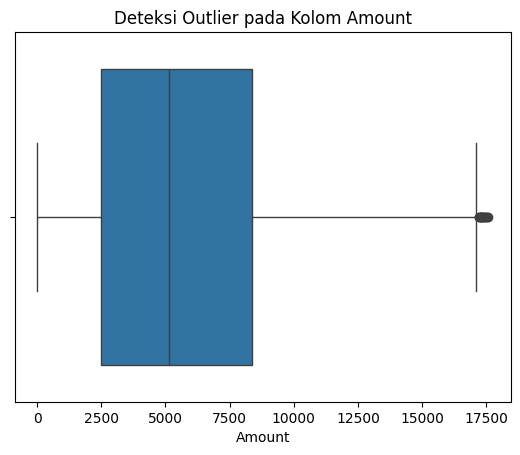

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat Box Plot untuk satu kolom (Amount)
sns.boxplot(x=df_filtered['Amount'])
plt.title('Deteksi Outlier pada Kolom Amount')
plt.show()

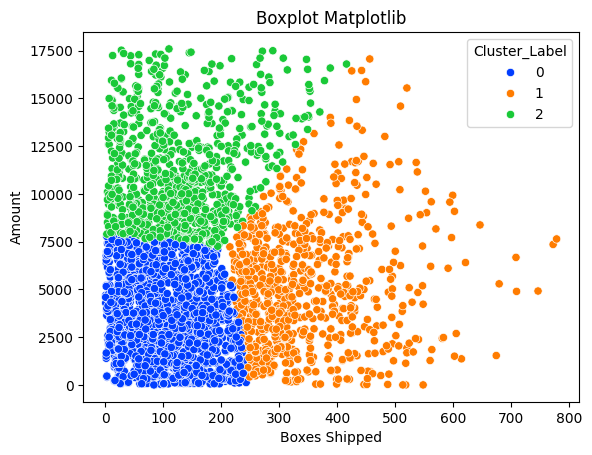

In [46]:
# scatterplot dengan pengelompokan
sns.scatterplot(data=df_filtered, x='Boxes Shipped', y= 'Amount', hue='Cluster_Label', palette='bright')
plt.title("Boxplot Matplotlib")
plt.show()

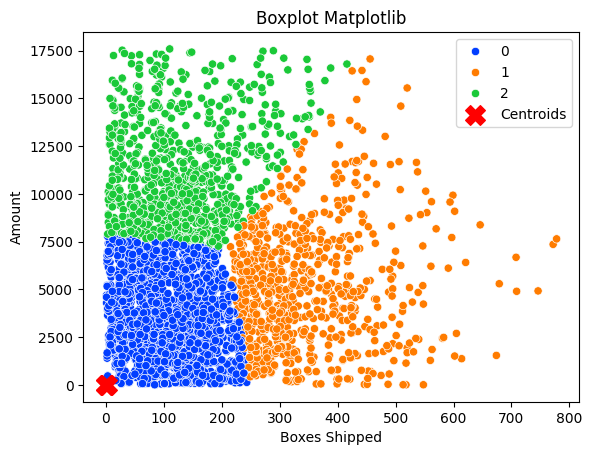

In [47]:
#gabungan scatterplot dan centroids
# scatterplot dengan pengelompokan
sns.scatterplot(data=df_filtered, x='Boxes Shipped', y= 'Amount', hue='Cluster_Label', palette='bright')
plt.title("Boxplot Matplotlib")
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', s=200, marker='X', label='Centroids')
plt.legend()
plt.show()

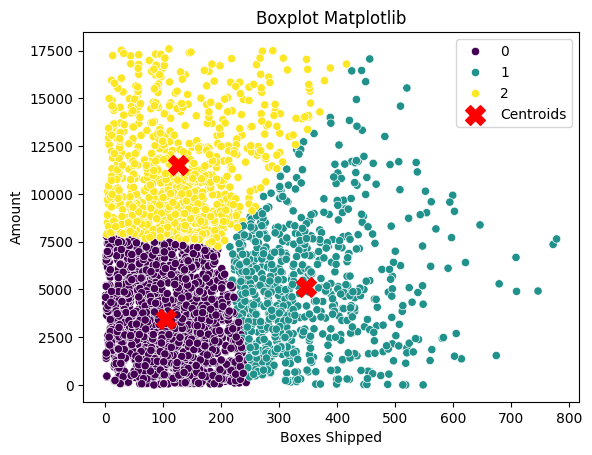

In [48]:
#gabungan scatterplot dan centroids
# scatterplot dengan pengelompokan
sns.scatterplot(data=df_filtered, x='Boxes Shipped', y= 'Amount', hue='Cluster_Label', palette='viridis')
plt.title("Boxplot Matplotlib")
centroidss = kmeans.cluster_centers_
centroids = alat_scalling.inverse_transform(centroidss)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', s=200, marker='X', label='Centroids')
plt.legend()
plt.show()

In [49]:
urutan_sales=df_filtered[['Sales Person', 'Amount','Boxes Shipped']]
urutan_sales

,Sales Person,Amount,Boxes Shipped
0,Jehu Rudeforth,5320.00,180
1,Van Tuxwell,7896.00,94
2,Gigi Bohling,4501.00,91
3,Jan Morforth,12726.00,342
4,Jehu Rudeforth,13685.00,184
...,...,...,...
3277,Karlen McCaffrey,5303.58,354
3278,Jehu Rudeforth,7339.32,121
3279,Ches Bonnell,616.09,238
3280,Dotty Strutley,2504.62,397


In [50]:
# EVALUASI MODEL
# kolom Amount dan Boxes Shipped untuk segmentasi
features = df[['Amount', 'Boxes Shipped']]

# Scaling=K-Means akurat
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [51]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # inertia_ adalah nilai WCSS

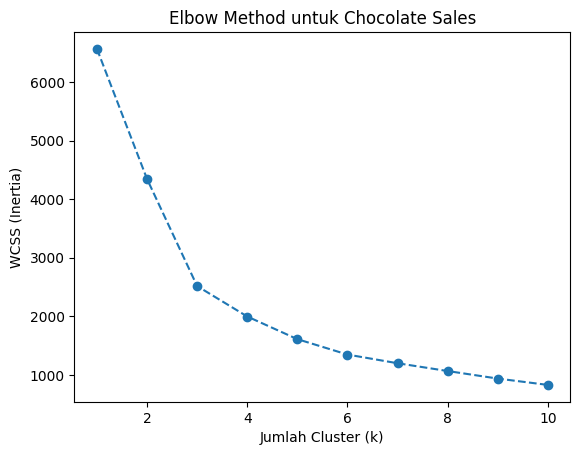

In [52]:
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method untuk Chocolate Sales')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS (Inertia)')
plt.show()


In [53]:
pip install fastapi uvicorn scikit-learn joblib pydantic pandas

In [54]:
import joblib
import pandas as pd
from sklearn.cluster import KMeans

# Mulai maukan ke API
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(data_scalled)

# Simpan model
joblib.dump(kmeans, "kmeans_chocolate.pkl")
print("Model berhasil disimpan tanpa error!")

Model berhasil disimpan tanpa error!


In [55]:
from google.colab import files
files.download('kmeans_chocolate.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
import threading
import time
import joblib
import pandas as pd
from fastapi import FastAPI
from pydantic import BaseModel
import uvicorn
import requests

# Setup FastAPI App
model = joblib.load("kmeans_chocolate.pkl")
app = FastAPI(title="Chocolate Sales Clustering API")


class SalesData(BaseModel):
  amount: float
  boxes_shipped: int


@app.post("/predict")
def predict_cluster(data: SalesData):
  features = [[data.amount, data.boxes_shipped]]
  cluster = model.predict(features)
  return {
      "amount": data.amount,
      "boxes_shipped": data.boxes_shipped,
      "assigned_cluster": int(cluster[0]),
  }


# Jalankan Uvicorn di Thread terpisah (Anti-Blocking di Colab!)
def run_server():
  uvicorn.run(app, host="127.0.0.1", port=8000, log_level="warning")


server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

# Beri waktu 2 detik untuk nyiapkan server
time.sleep(2)

# Tes langsung kirim data!
response = requests.post(
    "http://127.0.0.1:8000/predict", json={"amount": 5320.00, "boxes_shipped": 150}
)

print("HASIL RESPON API:", response.json())

ERROR:    [Errno 98] error while attempting to bind on address ('127.0.0.1', 8000): address already in use


HASIL RESPON API: {'amount': 5320.0, 'boxes_shipped': 150, 'assigned_cluster': 1}
